# Linear perceptron 

# 1. Generate a dataset

dimensions de X: (300, 2)
dimensions de y: (300, 1)


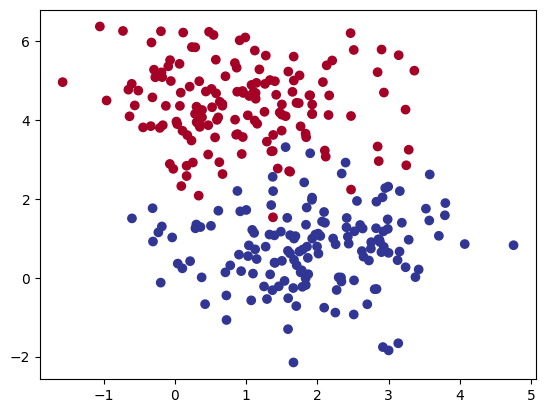

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score


# A dataset with 300 observations and 2 variables (features) x1 and x2 (petal length, petal width)
# Objective : train a model to discriminate between two types of flowers y=0 (blue) or 1 (green)
X, y = make_blobs(n_samples=300, n_features=2, centers=2, random_state=0)
y= y.reshape(y.shape[0],1)

print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)

plt.scatter(X[:,0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.savefig('data_linear.jpeg',dpi=300,bbox_inches='tight')

# 2. Fundamental Functions of the model

4 steps:
- `Forward Propagation`: Propagation of data from the first to the last layer to produce the ŷ output. This step consists of calculating the outputs of each layer by successively applying linear transformations (weighted sums) and activation functions. It's done here with the function `predict`.
- `Cost function`: Calculation of the error for all pairs (X(i), y(i)) using a cost function adapted to the problem (MSE for regression, cross-entropy for classification, etc.). It's done here with the function `log_loss`.
- `Backward Propagation`: Backpropagation to measure how the cost function varies with respect to each layer. This step involves calculating the gradients of the error with respect to all network parameters using the chain rule. It's done here with the function `gradients`.
- `Gradient descent`: Correction of each model parameter using the previously calculated gradients and a learning step. This step can be performed by various optimization algorithms (classical gradient descent, SGD, Adam, etc.). It's done here with the function `update`.

`initialisation(X)`: Creates random initial weights W and bias b for a neural network based on input data dimensions.

In [3]:
#Initialization of W and b
def initialisation(X):
    W = np.random.randn(X.shape[1], 1) #X1, x2 ==> W1, W2
    b = np.random.randn(1) # b is real number
    return (W, b)

`model(X, W, b)`: Computes the forward propagation by calculating Z = WX^T + b and applying sigmoid activation function.

In [4]:
# Linear Model
def model(X, W, b):
    Z = X.dot(W) + b   #Z=WX^T+b 
    A = 1 / (1 + np.exp(-Z)) #Activation sigmoid (A.shape ==> (300,1)) ==> 300 outcomes, one per sample
    return A

`log_loss(A, y)`: Calculates the binary cross-entropy loss between predicted probabilities A and actual labels y.

In [5]:
# Cost function (binary cross-entropy)
def log_loss(A, y):
    return 1 / len(y) * np.sum(-y * np.log(A) - (1 - y) * np.log(1 - A))
 
#log_loss(A,y) ==> real number

`gradients(A, X, y)`: Computes the gradients of the loss function with respect to weights W and bias b.

In [6]:
# Gradients dL/dW and dL/db
def gradients(A, X, y):
    dW = 1 / len(y) * np.dot(X.T, A - y)
    db = 1 / len(y) * np.sum(A - y)
    return (dW, db)

#dW,db=gradients(A,X,y)
#dW.shape ==> same dimension as W (2,1)
#db.shape ==> real number 

`update(dW, db, W, b, learning_rate)`: Updates the model parameters (weights and bias) using gradient descent.

In [7]:
# Update Gradient descent 
def update(dW, db, W, b, learning_rate):
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return (W, b)

`predict(X, W, b)`: Makes binary predictions by applying the model and thresholding at 0.5.

In [8]:
# Function to predict
def predict(X, W, b):
    A = model(X, W, b)
    #print(A) #to see the probabilities
    return A >= 0.5
# if A>0.5 ==> True

`artificial_neuron(X, y, learning_rate, n_iter)`: Implements a complete perceptron training process, including initialization, training iterations, and evaluation.

In [9]:
# Aggregation of the function to construct the artificial neuron
def artificial_neuron(X, y, learning_rate = 0.01, n_iter = 200):
    
    # Train the model
    W, b = initialisation(X)
    Loss = []
    for i in range(n_iter):
        A = model(X, W, b)  #A : result of the model
        Loss.append(log_loss(A, y))
        dW, db = gradients(A, X, y)
        W, b = update(dW, db, W, b, learning_rate)

    # Predictions y_pred for the 300 samples
    y_pred = predict(X, W, b)
    print('Accuracy =', round(accuracy_score(y, y_pred)*100,3),'%')
    
    # Show the loss function (errors) at each iteration
    plt.plot(Loss)
    plt.show()
    
    # Return the parameters of the model to use them after to predict with the same model without retrain
    return (W, b)
    

# 3. Application of the model

Accuracy = 88.333 %


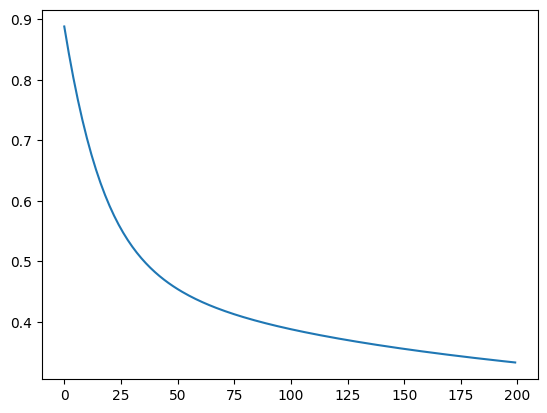

In [10]:
W, b = artificial_neuron(X, y)

In [11]:
W,b

(array([[ 0.87063225],
        [-0.54609398]]),
 array([-0.48040576]))

# 4. Predict a new sample

[ True]


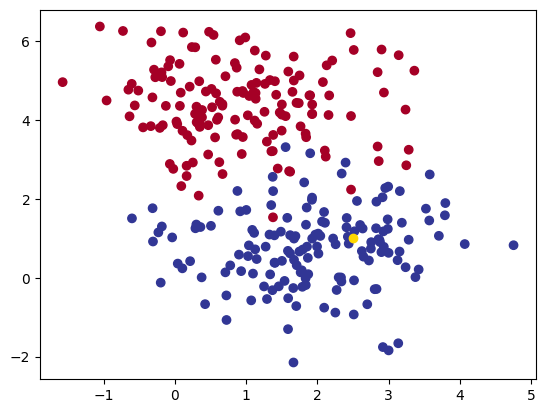

In [12]:
new_sample=np.array([2.5,1])
plt.scatter(X[:,0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.scatter(new_sample[0], new_sample[1], color='gold')
print(predict(new_sample, W, b))

##Probability (1-A)
plt.savefig('gold_point.jpeg',dpi=300,bbox_inches='tight')

# 5. Decision frontier

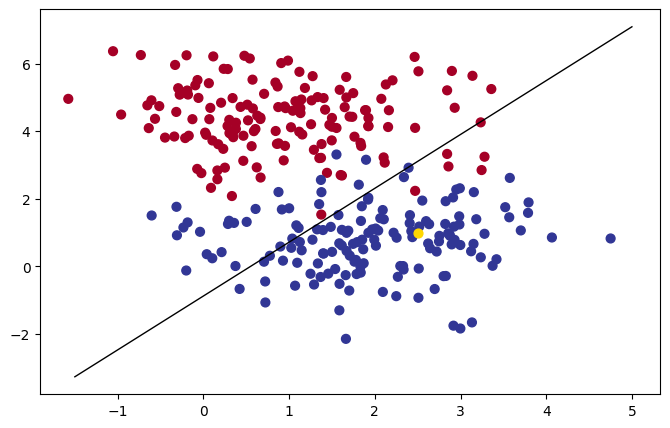

In [13]:
#Compare the errors to the Accuracy value

# decision frontier : z=0 (if z<0 ==> ypred=0; otherwise ypred=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X[:,0], X[:, 1], c=y, cmap=plt.cm.RdYlBu,s=40)
plt.scatter(new_sample[0], new_sample[1], c='gold',s=40)
x1 = np.linspace(-1.5, 5)
x2 = ( - W[0] * x1 - b) / W[1] #à Z=0 A=0.5

ax.plot(x1, x2, c='k', lw=1)
plt.savefig('decision_frontier.jpeg',dpi=300,bbox_inches='tight')


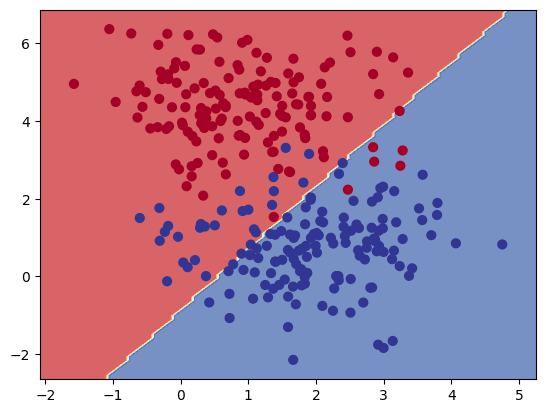

In [14]:
# For the visualisation of the decision boundaries 

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min,x_max, 100), np.linspace(y_min, y_max, 100))
x_in = np.c_[xx.ravel(), yy.ravel()]

y_pred = predict(x_in, W, b)
y_pred = np.round(y_pred).reshape(xx.shape)

plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7 )
plt.scatter(X[:,0], X[:,1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.savefig('decision_boundaries.jpeg',dpi=300,bbox_inches='tight')
plt.show()

# 6. Données circulaires

dimension of X: (500, 2)
dimension of y: (500, 1)


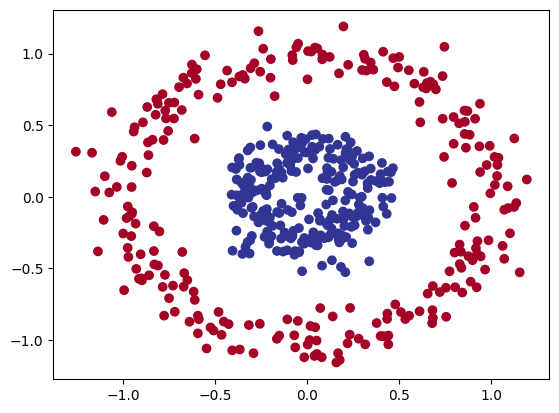

In [15]:
from sklearn.datasets import make_circles

X_circ, y_circ = make_circles(n_samples=500, noise=0.1, factor=0.3, random_state=0)
y_circ = y_circ.reshape((y_circ.shape[0],1))

print('dimension of X:', X_circ.shape)
print('dimension of y:', y_circ.shape)

plt.scatter(X_circ[:,0], X_circ[:,1], c=y_circ, cmap=plt.cm.RdYlBu)
plt.savefig('data_circular.jpeg',dpi=300,bbox_inches='tight')
plt.show()

Accuracy = 50.0 %


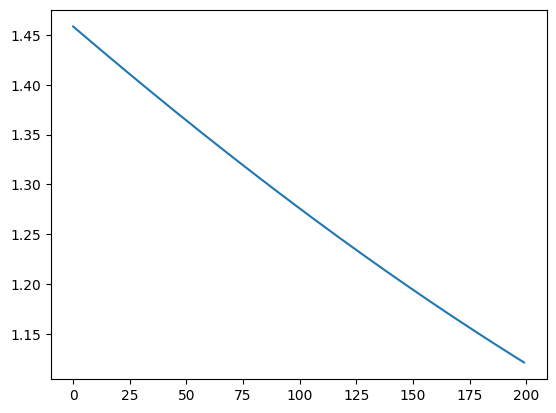

In [16]:
W_circ, b_circ = artificial_neuron(X_circ, y_circ)

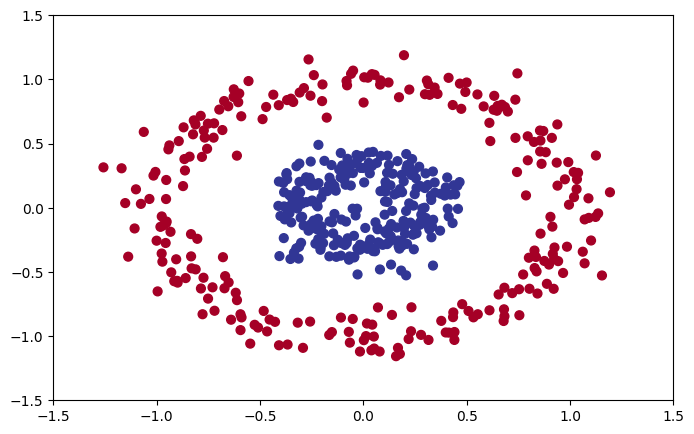

In [17]:
#Compare the errors to the Accuracy value

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(X_circ[:,0], X_circ[:, 1], c=y_circ, cmap=plt.cm.RdYlBu,s=40)
x1 = np.linspace(-1.5, 1.5)
x2 = ( - W_circ[0] * x1 - b_circ) / W_circ[1] 
ax.set_xlim((-1.5,1.5))
ax.set_ylim((-1.5,1.5))
ax.plot(x1, x2, c='k')
plt.savefig('data_circular_frontier.jpeg',dpi=300,bbox_inches='tight')

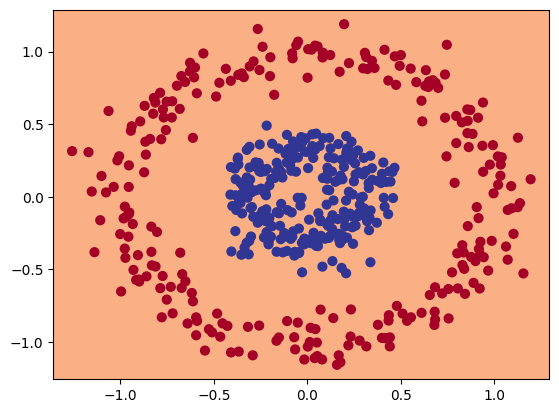

In [18]:
# For the visualisation of the decision boundaries 

x_min_circ, x_max_circ = X_circ[:, 0].min() - 0.1, X_circ[:, 0].max() + 0.1
y_min_circ, y_max_circ = X_circ[:, 1].min() - 0.1, X_circ[:, 1].max() + 0.1

xx_circ, yy_circ = np.meshgrid(np.linspace(x_min_circ,x_max_circ, 100), np.linspace(y_min_circ, y_max_circ, 100))
x_in_circ = np.c_[xx_circ.ravel(), yy_circ.ravel()]

y_pred_circ = predict(x_in_circ, W_circ, b_circ)
y_pred_circ = np.round(y_pred_circ).reshape(xx_circ.shape)
 
plt.contourf(xx_circ, yy_circ, y_pred_circ, cmap=plt.cm.RdYlBu, alpha=0.7 )
plt.scatter(X_circ[:,0], X_circ[:,1], c=y_circ, s=40, cmap=plt.cm.RdYlBu)
plt.xlim(xx_circ.min(), xx_circ.max())
plt.ylim(yy_circ.min(), yy_circ.max())
plt.savefig('data_circular_boundaries.jpeg',dpi=300,bbox_inches='tight')